In [1]:
import pandas as pd 


In [3]:
df = pd.read_csv(r"C:\Users\veda\Downloads\archive\Sample - Superstore.csv",encoding="latin1")

In [5]:
df.head(2)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820


In [6]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

In [10]:
df['Postal Code'] = df['Postal Code'].astype(str)

In [16]:
df["Order Date"]

0      2016-11-08
1      2016-11-08
2      2016-06-12
3      2015-10-11
4      2015-10-11
          ...    
9989   2014-01-21
9990   2017-02-26
9991   2017-02-26
9992   2017-02-26
9993   2017-05-04
Name: Order Date, Length: 9994, dtype: datetime64[ns]

In [19]:
df.dtypes

Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code              object
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
dtype: object

In [20]:
df['Category'].unique()

array(['Furniture', 'Office Supplies', 'Technology'], dtype=object)

In [21]:
df['Category'] = df['Category'].str.strip().str.title()
df['Segment'] = df['Segment'].str.strip().str.title()

In [22]:
Q1 = df['Sales'].quantile(0.25)
Q3 = df['Sales'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Sales'] < lower) | (df['Sales'] > upper)]

print(len(outliers))

1167


In [23]:
df['Year'] = df['Order Date'].dt.year

In [33]:
df['Month'] = df['Order Date'].dt.month_name()

In [34]:
df['Day'] = df['Order Date'].dt.day_name()

In [35]:
df[['Order Date','Year','Month','Day']].head()

,Order Date,Year,Month,Day
0,2016-11-08,2016,November,Tuesday
1,2016-11-08,2016,November,Tuesday
2,2016-06-12,2016,June,Sunday
3,2015-10-11,2015,October,Sunday
4,2015-10-11,2015,October,Sunday


In [36]:
df.to_csv("Superstore_Cleaned.csv", index=False)

In [38]:
import os
os.getcwd()

'C:\\Users\\veda'

In [39]:
monthly_sales = df.groupby('Month')['Sales'].sum().reset_index()
monthly_sales

,Month,Sales
0,April,137762.1286
1,August,159044.0630
2,December,325293.5035
3,February,59751.2514
4,January,94924.8356
5,July,147238.0970
6,June,152718.6793
7,March,205005.4888
8,May,155028.8117
9,November,352461.0710


In [40]:
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

monthly_sales['Month'] = pd.Categorical(
    monthly_sales['Month'],
    categories=month_order,
    ordered=True
)

monthly_sales = monthly_sales.sort_values('Month')

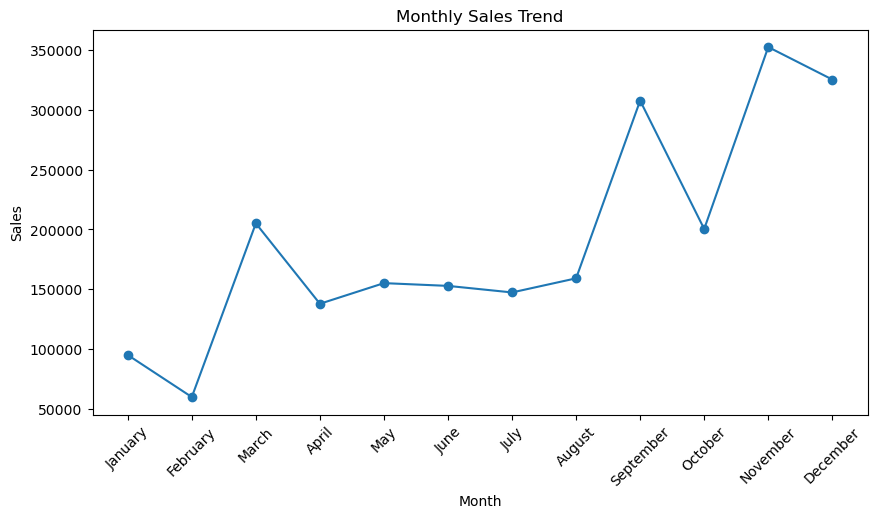

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(monthly_sales['Month'], monthly_sales['Sales'], marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.xticks(rotation=45)
plt.show()

In [45]:
yearly_sales = df.groupby('Year')['Sales'].sum().reset_index()
yearly_sales

,Year,Sales
0,2014,484247.4981
1,2015,470532.5090
2,2016,609205.5980
3,2017,733215.2552


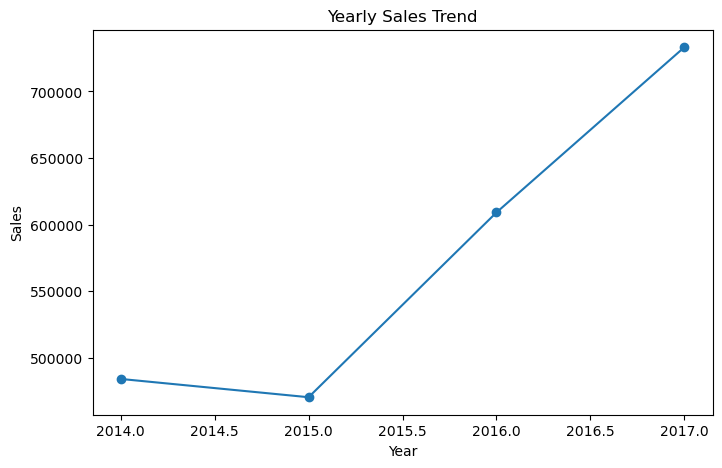

In [46]:
plt.figure(figsize=(8,5))
plt.plot(yearly_sales['Year'], yearly_sales['Sales'], marker='o')
plt.title('Yearly Sales Trend')
plt.xlabel('Year')
plt.ylabel('Sales')
plt.show()

In [47]:
best_month = monthly_sales.loc[monthly_sales['Sales'].idxmax()]
worst_month = monthly_sales.loc[monthly_sales['Sales'].idxmin()]

print(best_month)
print(worst_month)

Month      November
Sales    352461.071
Name: 9, dtype: object
Month      February
Sales    59751.2514
Name: 3, dtype: object


In [48]:
best_year = yearly_sales.loc[yearly_sales['Sales'].idxmax()]
worst_year = yearly_sales.loc[yearly_sales['Sales'].idxmin()]

print(best_year)
print(worst_year)

Year       2017.0000
Sales    733215.2552
Name: 3, dtype: float64
Year       2015.000
Sales    470532.509
Name: 1, dtype: float64


In [49]:
top_products = df.groupby('Product Name')['Sales'].sum().reset_index()

top_products = top_products.sort_values(
    by='Sales',
    ascending=False
)

top_products.head(10)

,Product Name,Sales
404,Canon imageCLASS 2200 Advanced Copier,61599.824
650,Fellowes PB500 Electric Punch Plastic Comb Bin...,27453.384
444,Cisco TelePresence System EX90 Videoconferenci...,22638.480
786,HON 5400 Series Task Chairs for Big and Tall,21870.576
686,GBC DocuBind TL300 Electric Binding System,19823.479
688,GBC Ibimaster 500 Manual ProClick Binding System,19024.500
805,Hewlett Packard LaserJet 3310 Copier,18839.686
787,HP Designjet T520 Inkjet Large Format Printer ...,18374.895
683,GBC DocuBind P400 Electric Binding System,17965.068
813,High Speed Automatic Electric Letter Opener,17030.312


In [52]:
top_quantitys = df.groupby('Product Name')['Quantity'].sum().reset_index()

top_quantity = top_quantitys.sort_values(
    by='Quantity',
    ascending=False
)

top_quantity.head(10)

,Product Name,Quantity
1499,Staples,215
1493,Staple envelope,170
537,Easy-staple paper,150
1500,Staples in misc. colors,86
942,KI Adjustable-Height Table,74
259,Avery Non-Stick Binders,71
1511,Storex Dura Pro Binders,71
699,GBC Premium Transparent Covers with Diagonal L...,67
1450,"Situations Contoured Folding Chairs, 4/Set",64
1497,Staple-based wall hangings,62


In [53]:
category_sales = df.groupby('Category')['Sales'].sum().reset_index()

category_sales = category_sales.sort_values(
    by='Sales',
    ascending=False
)

category_sales

,Category,Sales
2,Technology,836154.0330
0,Furniture,741999.7953
1,Office Supplies,719047.0320


In [54]:
category_profit = df.groupby('Category')['Profit'].sum().reset_index()

category_profit = category_profit.sort_values(
    by='Profit',
    ascending=False
)

category_profit

,Category,Profit
2,Technology,145454.9481
1,Office Supplies,122490.8008
0,Furniture,18451.2728


In [55]:
top_profit_products = df.groupby('Product Name')['Profit'].sum().reset_index()

top_profit_products = top_profit_products.sort_values(
    by='Profit',
    ascending=False
)

top_profit_products.head(10)

,Product Name,Profit
404,Canon imageCLASS 2200 Advanced Copier,25199.9280
650,Fellowes PB500 Electric Punch Plastic Comb Bin...,7753.0390
805,Hewlett Packard LaserJet 3310 Copier,6983.8836
400,Canon PC1060 Personal Laser Copier,4570.9347
787,HP Designjet T520 Inkjet Large Format Printer ...,4094.9766
165,Ativa V4110MDD Micro-Cut Shredder,3772.9461
19,"3D Systems Cube Printer, 2nd Generation, Magenta",3717.9714
1276,Plantronics Savi W720 Multi-Device Wireless He...,3696.2820
895,Ibico EPK-21 Electric Binding System,3345.2823
1840,Zebra ZM400 Thermal Label Printer,3343.5360


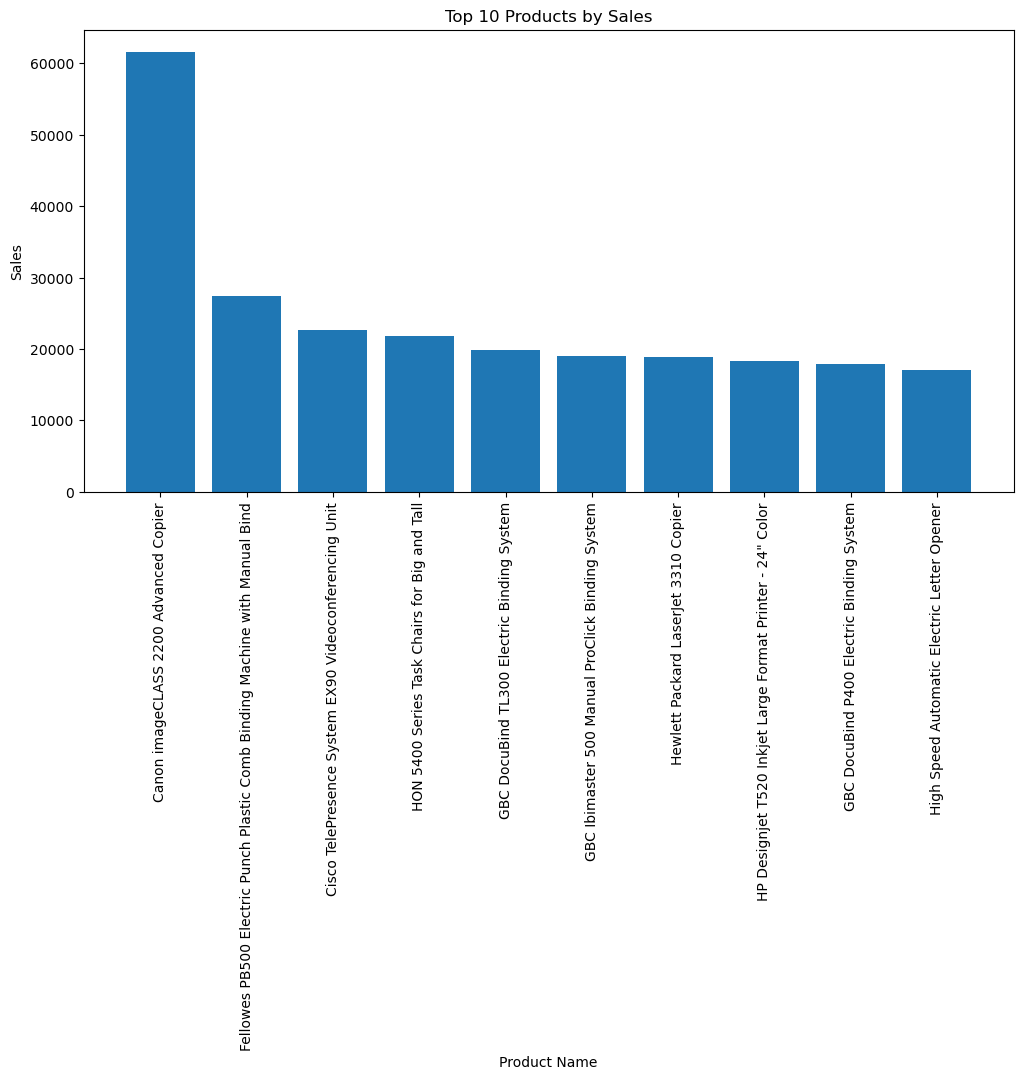

In [71]:
import matplotlib.pyplot as plt

top10 = top_products.head(10)

plt.figure(figsize=(12,6))
plt.bar(top10['Product Name'], top10['Sales'])

plt.title('Top 10 Products by Sales')
plt.xlabel('Product Name')
plt.ylabel('Sales')

plt.xticks(rotation=90)
plt.show()

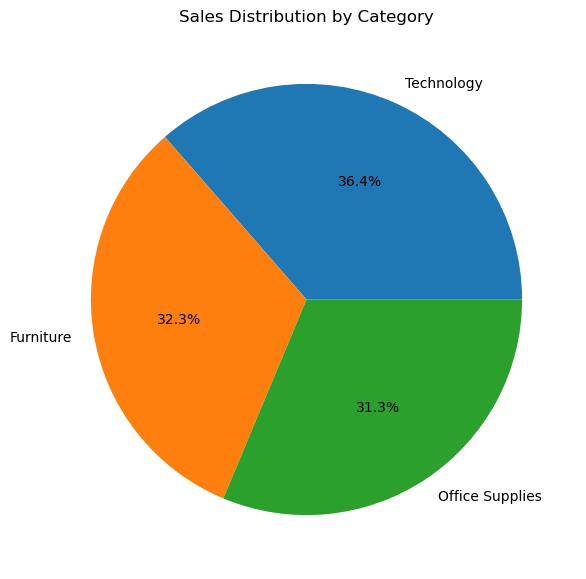

In [58]:
plt.figure(figsize=(7,7))

plt.pie(
    category_sales['Sales'],
    labels=category_sales['Category'],
    autopct='%1.1f%%'
)

plt.title('Sales Distribution by Category')
plt.show()

In [59]:
best_category = category_sales.loc[category_sales['Sales'].idxmax()]
print(best_category)

Category    Technology
Sales       836154.033
Name: 2, dtype: object


In [61]:
state_sales = df.groupby('State')['Sales'].sum().reset_index()

state_sales = state_sales.sort_values(
    by='Sales',
    ascending=False
)

state_sales.head(5)

,State,Sales
3,California,457687.6315
30,New York,310876.2710
41,Texas,170188.0458
45,Washington,138641.2700
36,Pennsylvania,116511.9140


In [63]:
state_sales.tail(5)

,State,Sales
48,Wyoming,1603.136
39,South Dakota,1315.560
17,Maine,1270.530
46,West Virginia,1209.824
32,North Dakota,919.910


In [64]:
city_sales = df.groupby('City')['Sales'].sum().reset_index()

city_sales = city_sales.sort_values(
    by='Sales',
    ascending=False
)

city_sales.head(10)

,City,Sales
329,New York City,256368.1610
266,Los Angeles,175851.3410
452,Seattle,119540.7420
438,San Francisco,112669.0920
374,Philadelphia,109077.0130
207,Houston,64504.7604
80,Chicago,48539.5410
437,San Diego,47521.0290
216,Jacksonville,44713.1830
464,Springfield,43054.3420


In [65]:
region_sales = df.groupby('Region')['Sales'].sum().reset_index()

region_sales = region_sales.sort_values(
    by='Sales',
    ascending=False
)

region_sales

,Region,Sales
3,West,725457.8245
1,East,678781.2400
0,Central,501239.8908
2,South,391721.9050


In [66]:
best_region = region_sales.loc[
    region_sales['Sales'].idxmax()
]

print(best_region)

Region           West
Sales     725457.8245
Name: 3, dtype: object


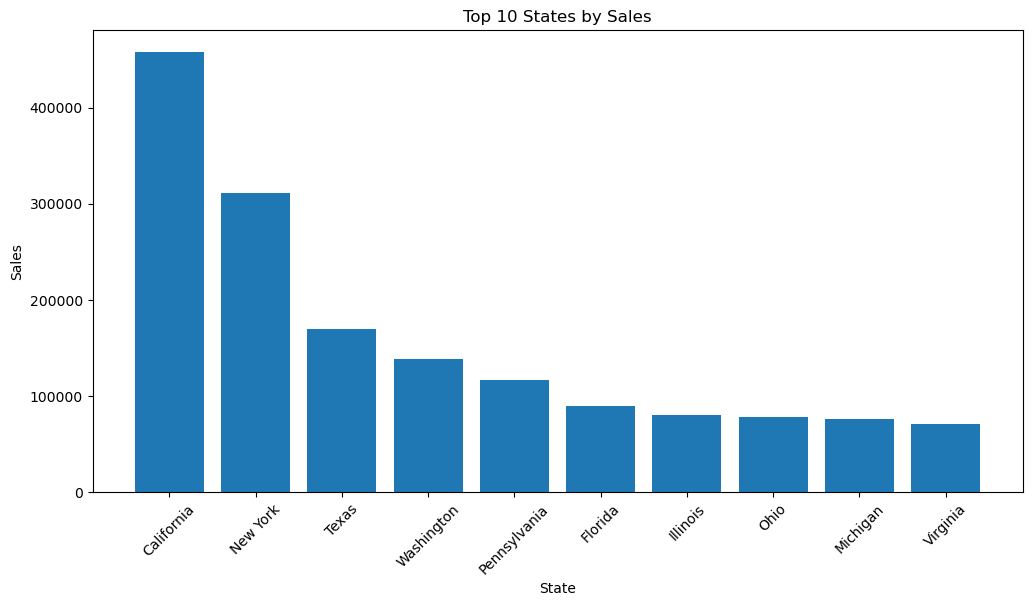

In [67]:


top10_states = state_sales.head(10)

plt.figure(figsize=(12,6))

plt.bar(
    top10_states['State'],
    top10_states['Sales']
)

plt.title('Top 10 States by Sales')
plt.xlabel('State')
plt.ylabel('Sales')

plt.xticks(rotation=45)

plt.show()

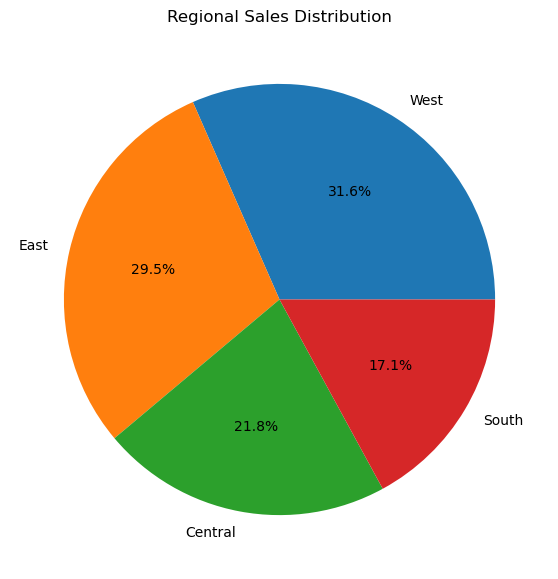

In [68]:
plt.figure(figsize=(7,7))

plt.pie(
    region_sales['Sales'],
    labels=region_sales['Region'],
    autopct='%1.1f%%'
)

plt.title('Regional Sales Distribution')

plt.show()

In [69]:
state_orders = df.groupby('State')['Order ID'].count().reset_index()

state_orders = state_orders.sort_values(
    by='Order ID',
    ascending=False
)

state_orders.head(10)

,State,Order ID
3,California,2001
30,New York,1128
41,Texas,985
36,Pennsylvania,587
45,Washington,506
11,Illinois,492
33,Ohio,469
8,Florida,383
20,Michigan,255
31,North Carolina,249


In [72]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

In [73]:
reference_date = df['Order Date'].max()

print(reference_date)

2017-12-30 00:00:00


In [74]:
rfm = df.groupby('Customer ID').agg({
    'Order Date': lambda x: (reference_date - x.max()).days,
    'Order ID': 'nunique',
    'Sales': 'sum'
}).reset_index()

In [75]:
rfm.columns = [
    'Customer ID',
    'Recency',
    'Frequency',
    'Monetary'
]

rfm.head()

,Customer ID,Recency,Frequency,Monetary
0,AA-10315,184,5,5563.560
1,AA-10375,19,9,1056.390
2,AA-10480,259,4,1790.512
3,AA-10645,55,6,5086.935
4,AB-10015,415,3,886.156


In [76]:
rfm['R_Score'] = pd.qcut(
    rfm['Recency'],
    5,
    labels=[5,4,3,2,1]
)

In [77]:
rfm['F_Score'] = pd.qcut(
    rfm['Frequency'].rank(method='first'),
    5,
    labels=[1,2,3,4,5]
)

In [78]:
rfm['M_Score'] = pd.qcut(
    rfm['Monetary'],
    5,
    labels=[1,2,3,4,5]
)

In [79]:
rfm['RFM_Score'] = (
    rfm['R_Score'].astype(str) +
    rfm['F_Score'].astype(str) +
    rfm['M_Score'].astype(str)
)

rfm.head()

,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,AA-10315,184,5,5563.560,2,2,5,225
1,AA-10375,19,9,1056.390,5,5,2,552
2,AA-10480,259,4,1790.512,1,1,3,113
3,AA-10645,55,6,5086.935,3,3,5,335
4,AB-10015,415,3,886.156,1,1,1,111


In [86]:
def segment_customer(row):

    if str(row['RFM_Score']) == '555':
        return 'High Value Customer'

    elif int(row['R_Score']) >= 4:
        return 'Potential Loyalist'

    elif int(row['R_Score']) <= 2:
        return 'At Risk'

    else:
        return 'Regular Customer'

In [83]:
rfm['Segment'] = rfm.apply(segment_customer, axis=1)

In [84]:
rfm['Segment'] = rfm.apply(
    segment_customer,
    axis=1
)

In [85]:
segment_counts = rfm['Segment'].value_counts()
print(segment_counts)

Segment
At Risk                316
Potential Loyalist     296
Regular Customer       159
High Value Customer     22
Name: count, dtype: int64


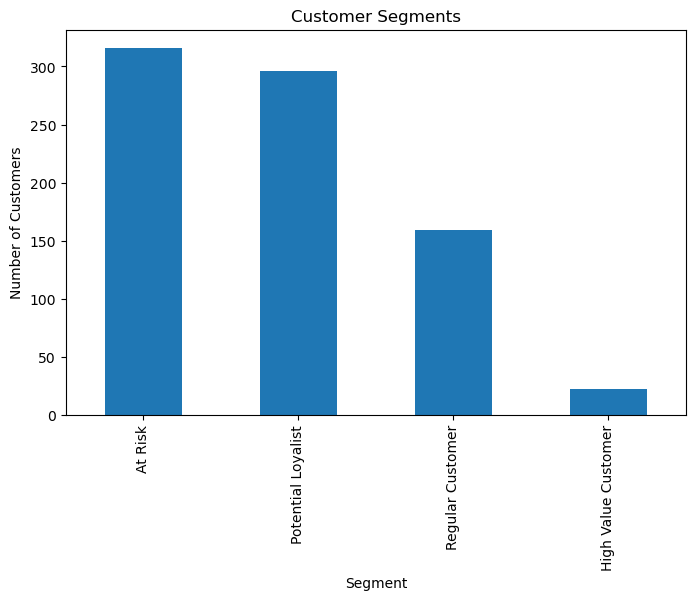

In [87]:
segment_counts.plot(
    kind='bar',
    figsize=(8,5)
)
plt.title('Customer Segments')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.show()

In [88]:
def segment_customer(row):

    r = int(row['R_Score'])
    f = int(row['F_Score'])
    m = int(row['M_Score'])

    if r >= 4 and f >= 4 and m >= 4:
        return 'High Value Customer'

    elif r >= 3 and f >= 3 and m >= 3:
        return 'Loyal Customer'

    elif r <= 2 and f >= 3 and m >= 3:
        return 'At Risk Customer'

    elif r >= 4 and f <= 2 and m <= 2:
        return 'New Customer'

    elif r <= 2 and f <= 2 and m <= 2:
        return 'Lost Customer'

    else:
        return 'Potential Loyalist'

In [89]:
rfm['Customer Segment'] = rfm.apply(
    segment_customer,
    axis=1
)

In [91]:
segment_counts = rfm['Customer Segment'].value_counts()
print(segment_counts)

Customer Segment
Potential Loyalist     253
Loyal Customer         159
Lost Customer          117
High Value Customer    106
At Risk Customer       101
New Customer            57
Name: count, dtype: int64


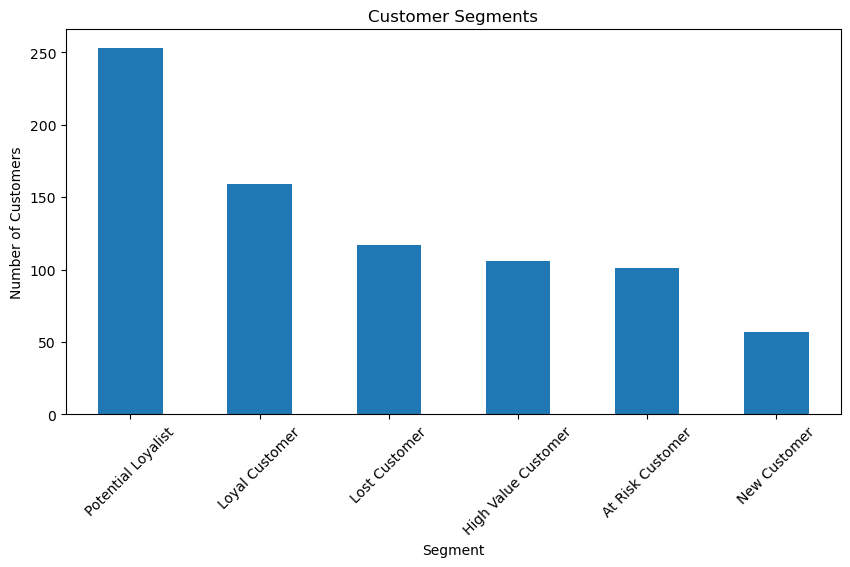

In [92]:


segment_counts.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Customer Segments')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')

plt.xticks(rotation=45)

plt.show()

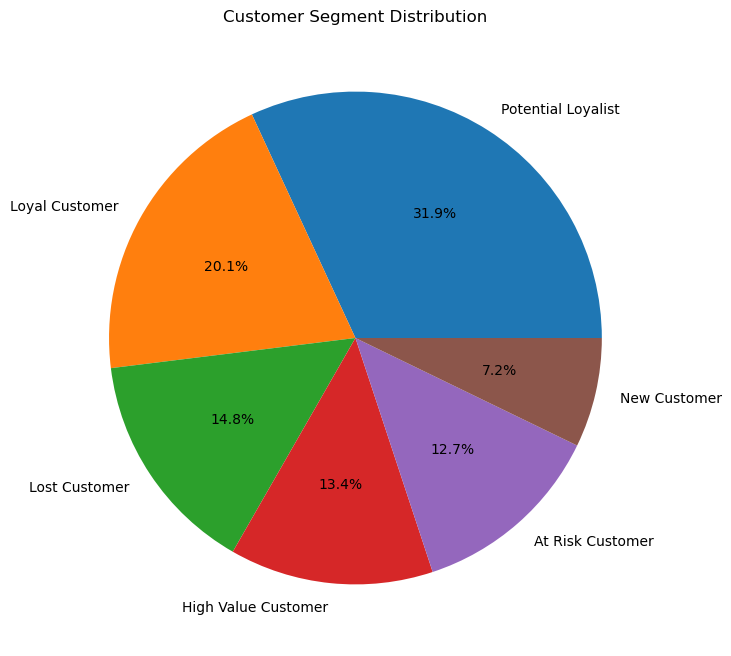

In [93]:
plt.figure(figsize=(8,8))

plt.pie(
    segment_counts,
    labels=segment_counts.index,
    autopct='%1.1f%%'
)

plt.title('Customer Segment Distribution')

plt.show()

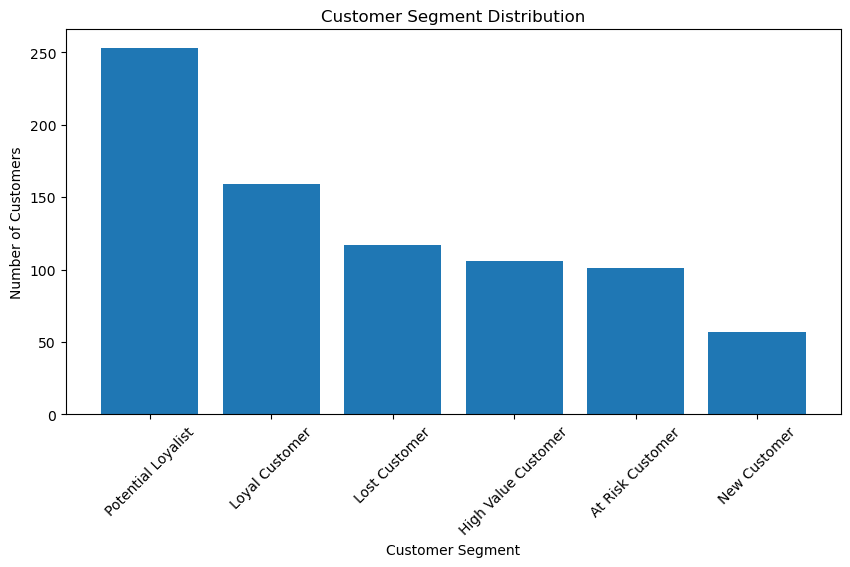

In [94]:
import matplotlib.pyplot as plt

segment_counts = rfm['Customer Segment'].value_counts()

plt.figure(figsize=(10,5))

plt.bar(
    segment_counts.index,
    segment_counts.values
)

plt.title('Customer Segment Distribution')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')

plt.xticks(rotation=45)

plt.show()

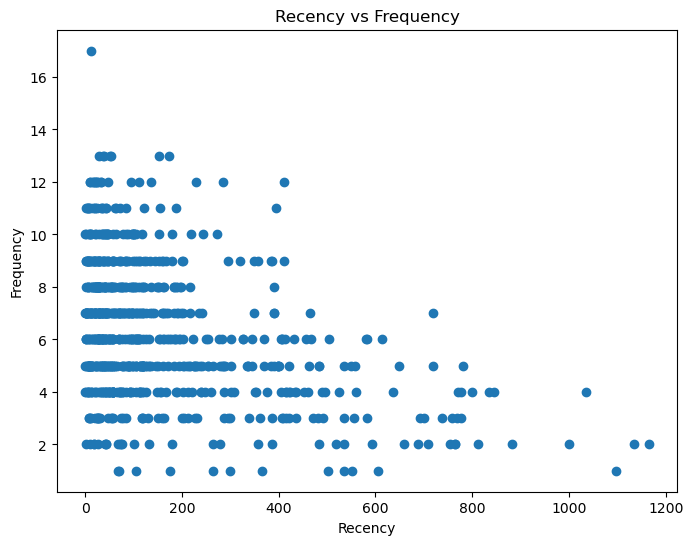

In [95]:
plt.figure(figsize=(8,6))

plt.scatter(
    rfm['Recency'],
    rfm['Frequency']
)

plt.title('Recency vs Frequency')
plt.xlabel('Recency')
plt.ylabel('Frequency')

plt.show()

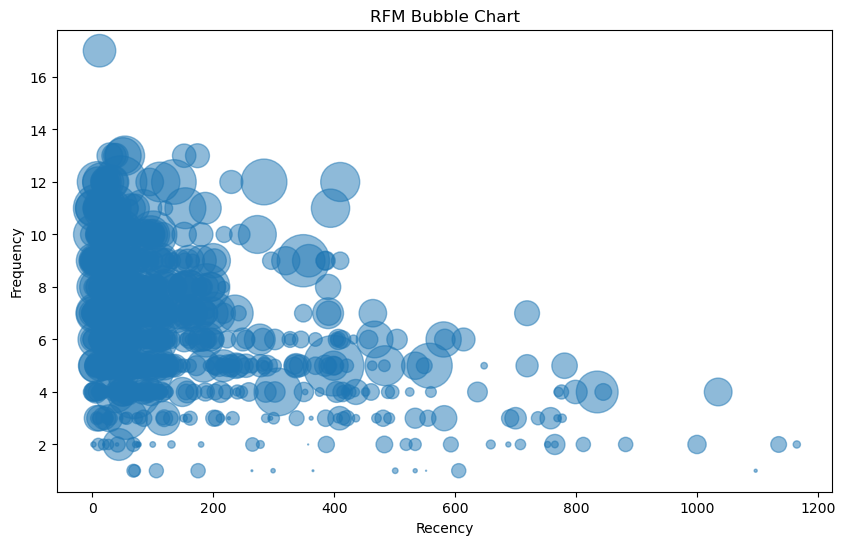

In [96]:
plt.figure(figsize=(10,6))

plt.scatter(
    rfm['Recency'],
    rfm['Frequency'],
    s=rfm['Monetary']/10,
    alpha=0.5
)

plt.title('RFM Bubble Chart')
plt.xlabel('Recency')
plt.ylabel('Frequency')

plt.show()

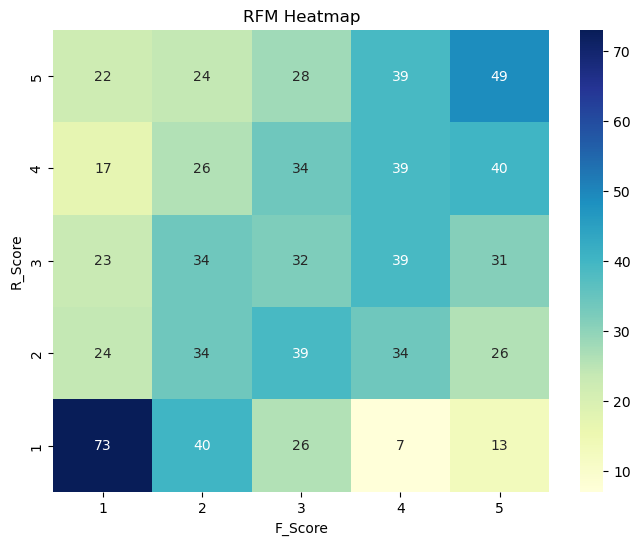

In [97]:
import seaborn as sns

heatmap_data = pd.crosstab(
    rfm['R_Score'],
    rfm['F_Score']
)

plt.figure(figsize=(8,6))

sns.heatmap(
    heatmap_data,
    annot=True,
    cmap='YlGnBu'
)

plt.title('RFM Heatmap')

plt.show()

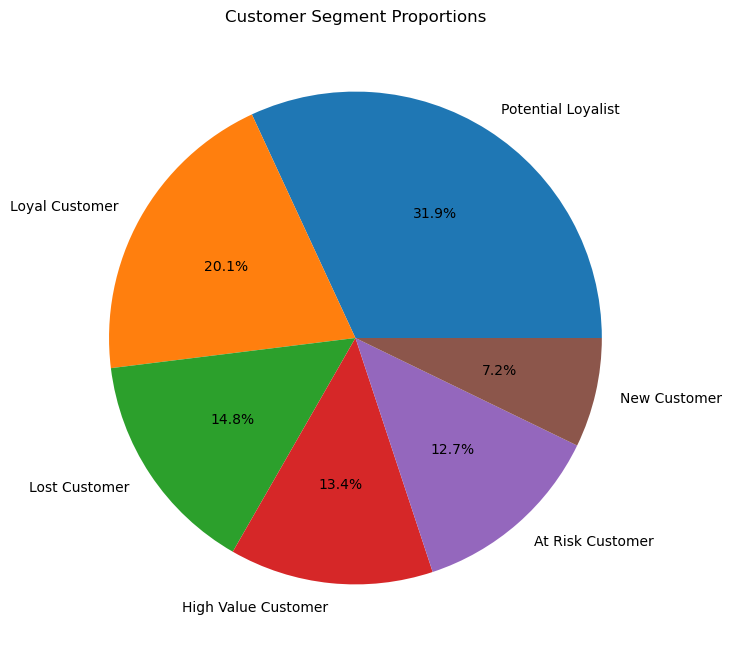

In [98]:
plt.figure(figsize=(8,8))

plt.pie(
    segment_counts.values,
    labels=segment_counts.index,
    autopct='%1.1f%%'
)

plt.title('Customer Segment Proportions')

plt.show()

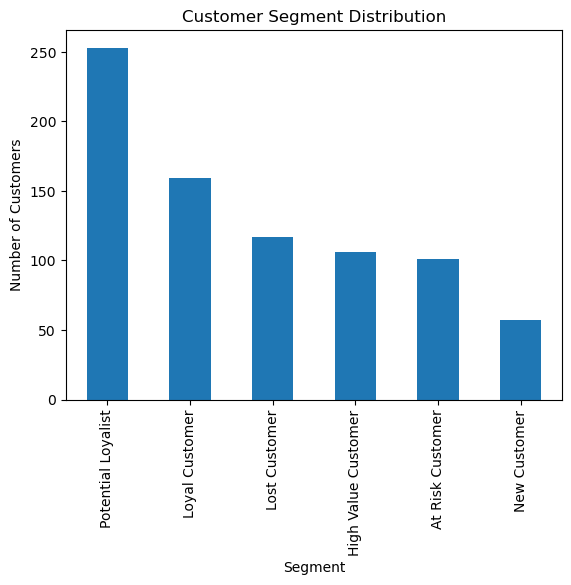

In [99]:
segment_counts = rfm['Customer Segment'].value_counts()

segment_counts.plot(kind='bar')

plt.title('Customer Segment Distribution')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')

plt.show()

In [101]:
df['Order Date'].head()

0   2016-11-08
1   2016-11-08
2   2016-06-12
3   2015-10-11
4   2015-10-11
Name: Order Date, dtype: datetime64[ns]

In [102]:
df['Year'] = df['Order Date'].dt.year

df['Month'] = df['Order Date'].dt.month

df['Week'] = df['Order Date'].dt.isocalendar().week

df['Day'] = df['Order Date'].dt.day

In [103]:
df[['Order Date','Year','Month','Week','Day']].head()

,Order Date,Year,Month,Week,Day
0,2016-11-08,2016,11,45,8
1,2016-11-08,2016,11,45,8
2,2016-06-12,2016,6,23,12
3,2015-10-11,2015,10,41,11
4,2015-10-11,2015,10,41,11


In [105]:
df.groupby('Order Date')['Sales'].sum().reset_index().head(2)



,Order Date,Sales
0,2014-01-03,16.448
1,2014-01-04,288.060


In [106]:
all_dates = pd.date_range(
    start=daily_sales['Order Date'].min(),
    end=daily_sales['Order Date'].max()
)

In [107]:
daily_sales = daily_sales.set_index('Order Date')

daily_sales = daily_sales.reindex(all_dates)

In [109]:
daily_sales['Sales'] = daily_sales['Sales'].fillna(0)

In [111]:
daily_sales = daily_sales.reset_index()

daily_sales.rename(
    columns={'index':'Order Date'},
    inplace=True
)

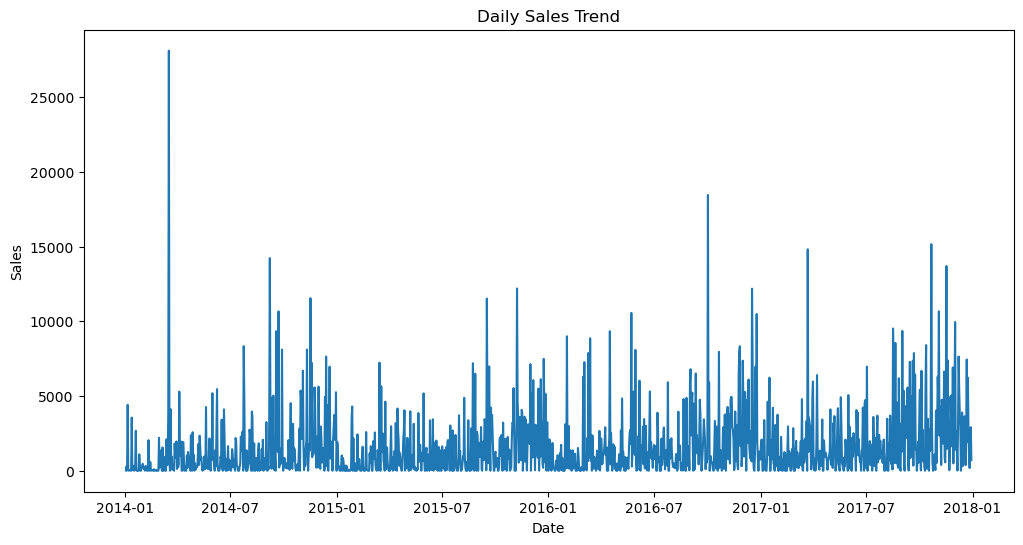

In [112]:
plt.figure(figsize=(12,6))

plt.plot(
    daily_sales['Order Date'],
    daily_sales['Sales']
)

plt.title('Daily Sales Trend')
plt.xlabel('Date')
plt.ylabel('Sales')

plt.show()

In [113]:
daily_sales = daily_sales.sort_values(
    by='Order Date'
)

In [114]:
daily_sales = daily_sales.set_index(
    'Order Date'
)

daily_sales.head()

,Sales
Order Date,
2014-01-03,16.448
2014-01-04,288.060
2014-01-05,19.536
2014-01-06,4407.100
2014-01-07,87.158


In [116]:
pip install statsmodels

Note: you may need to restart the kernel to use updated packages.


In [117]:
import pandas as pd

from statsmodels.tsa.holtwinters import ExponentialSmoothing

from sklearn.metrics import mean_squared_error

import matplotlib.pyplot as plt

import numpy as np

In [118]:
import pandas as pd

df['Order Date'] = pd.to_datetime(df['Order Date'])

monthly_sales = df.groupby(
    pd.Grouper(key='Order Date', freq='M')
)['Sales'].sum().reset_index()

monthly_sales.head()

C:\Users\veda\AppData\Local\Temp\ipykernel_15928\3532372876.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(key='Order Date', freq='M')


,Order Date,Sales
0,2014-01-31,14236.895
1,2014-02-28,4519.892
2,2014-03-31,55691.009
3,2014-04-30,28295.345
4,2014-05-31,23648.287


In [119]:
monthly_sales = monthly_sales.set_index('Order Date')

monthly_sales.head()

,Sales
Order Date,
2014-01-31,14236.895
2014-02-28,4519.892
2014-03-31,55691.009
2014-04-30,28295.345
2014-05-31,23648.287


In [120]:
train_size = int(len(monthly_sales) * 0.8)

train = monthly_sales[:train_size]
test = monthly_sales[train_size:]

In [121]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

model = ExponentialSmoothing(
    train['Sales'],
    trend='add',
    seasonal='add',
    seasonal_periods=12
)

fit_model = model.fit()

C:\Users\veda\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


In [122]:
predictions = fit_model.forecast(len(test))

In [123]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(
    mean_squared_error(
        test['Sales'],
        predictions
    )
)

print("RMSE:", rmse)

RMSE: 12645.758036976795


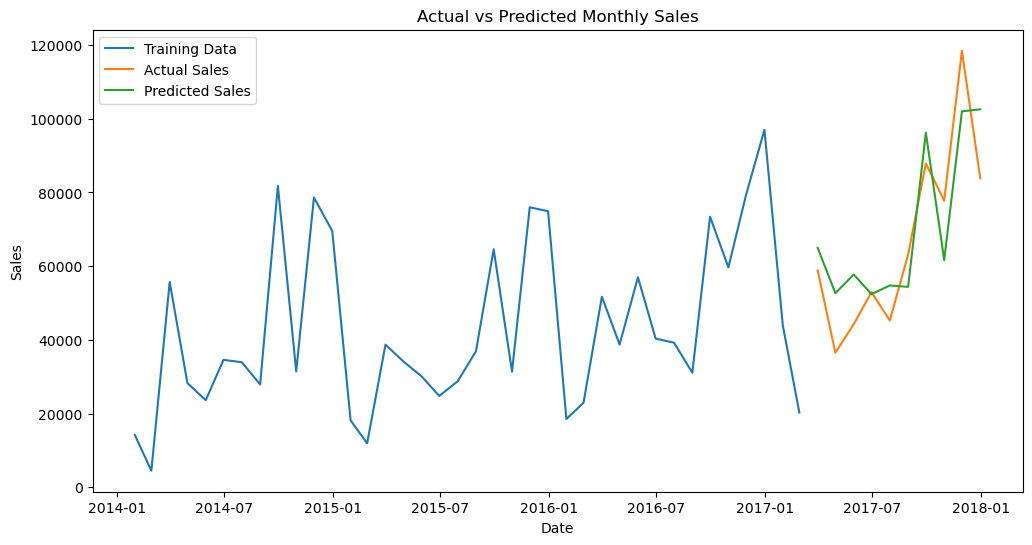

In [124]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    train.index,
    train['Sales'],
    label='Training Data'
)

plt.plot(
    test.index,
    test['Sales'],
    label='Actual Sales'
)

plt.plot(
    test.index,
    predictions,
    label='Predicted Sales'
)

plt.title('Actual vs Predicted Monthly Sales')

plt.xlabel('Date')
plt.ylabel('Sales')

plt.legend()

plt.show()

In [125]:
future_forecast = fit_model.forecast(12)

print(future_forecast)

2017-03-31     64967.396205
2017-04-30     52689.760006
2017-05-31     57740.821709
2017-06-30     52410.787961
2017-07-31     54781.158759
2017-08-31     54395.422818
2017-09-30     96220.305019
2017-10-31     61624.520884
2017-11-30    102001.799834
2017-12-31    102556.434279
2018-01-31     49226.605568
2018-02-28     41706.131149
Freq: ME, dtype: float64


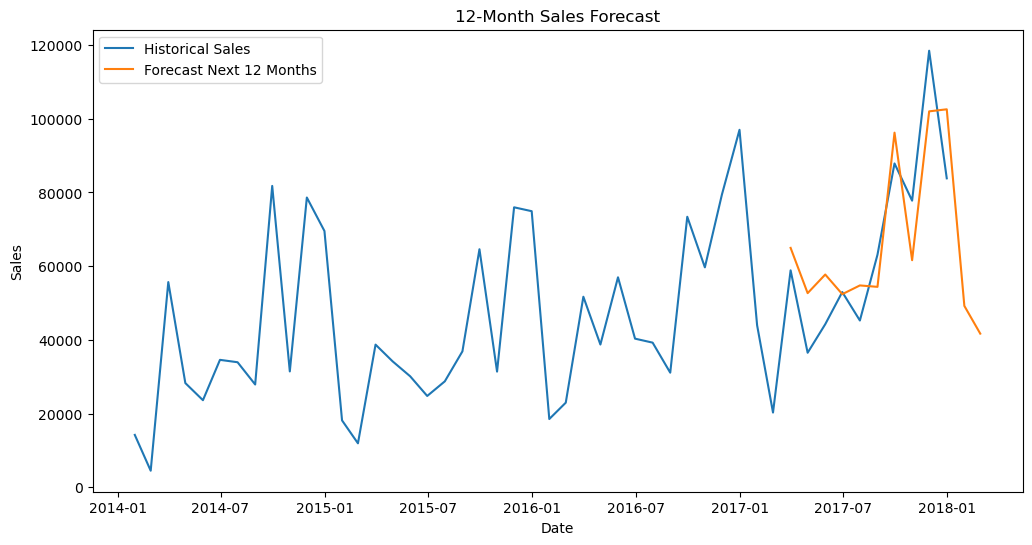

In [126]:
plt.figure(figsize=(12,6))

plt.plot(
    monthly_sales.index,
    monthly_sales['Sales'],
    label='Historical Sales'
)

plt.plot(
    future_forecast.index,
    future_forecast,
    label='Forecast Next 12 Months'
)

plt.title('12-Month Sales Forecast')

plt.xlabel('Date')
plt.ylabel('Sales')

plt.legend()

plt.show()

In [128]:
future_forecast = fit_model.forecast(12)
print(future_forecast)

2017-03-31     64967.396205
2017-04-30     52689.760006
2017-05-31     57740.821709
2017-06-30     52410.787961
2017-07-31     54781.158759
2017-08-31     54395.422818
2017-09-30     96220.305019
2017-10-31     61624.520884
2017-11-30    102001.799834
2017-12-31    102556.434279
2018-01-31     49226.605568
2018-02-28     41706.131149
Freq: ME, dtype: float64


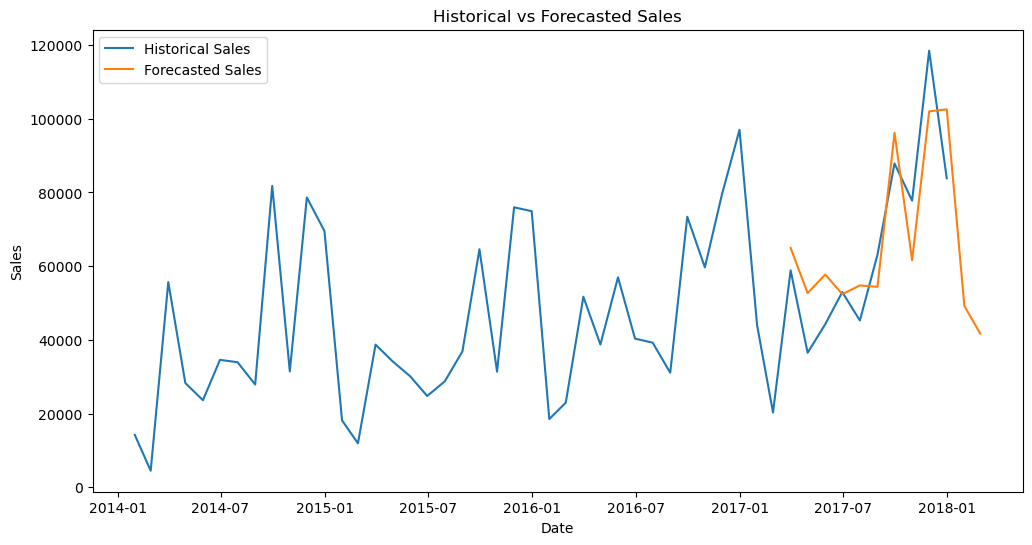

In [129]:
plt.figure(figsize=(12,6))
plt.plot(
    monthly_sales.index,
    monthly_sales['Sales'],
    label='Historical Sales'
)

plt.plot(
    future_forecast.index,
    future_forecast,
    label='Forecasted Sales'
)

plt.title('Historical vs Forecasted Sales')

plt.xlabel('Date')
plt.ylabel('Sales')

plt.legend()

plt.show()

In [130]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(
    mean_squared_error(
        test['Sales'],
        predictions
    )
)

print("RMSE:", rmse)

RMSE: 12645.758036976795


In [131]:
mape = np.mean(
    np.abs(
        (test['Sales'] - predictions)
        / test['Sales']
    )
) * 100

print("MAPE:", mape)

MAPE: 18.75031412183218


In [132]:
forecast_df = pd.DataFrame(
    {
        'Forecasted_Sales': future_forecast
    }
)

forecast_df.to_csv(
    'Sales_Forecast.csv'
)

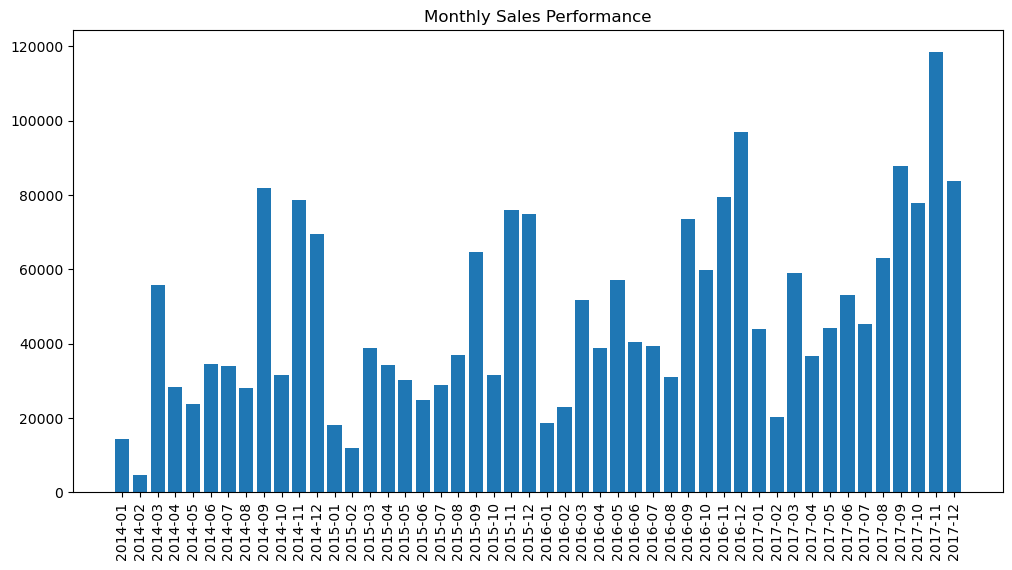

In [134]:
peak_months = monthly_sales.copy()

plt.figure(figsize=(12,6))

plt.bar(
    peak_months.index.strftime('%Y-%m'),
    peak_months['Sales']
)

plt.xticks(rotation=90)

plt.title('Monthly Sales Performance')

plt.show()

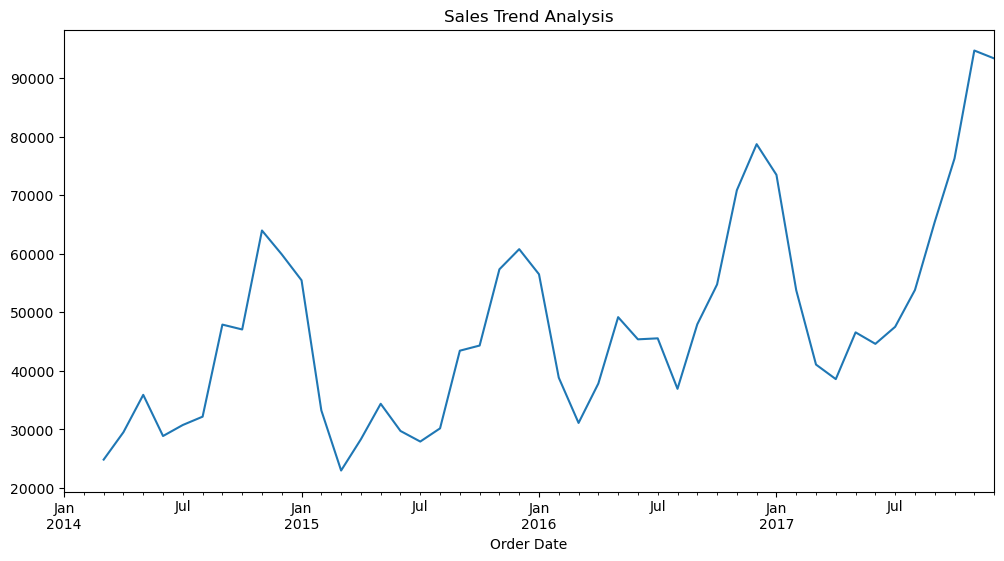

In [135]:
plt.figure(figsize=(12,6))

monthly_sales['Sales'].rolling(
    window=3
).mean().plot()

plt.title('Sales Trend Analysis')

plt.show()

In [136]:
forecast_df = pd.DataFrame({
    'Date': future_forecast.index,
    'Predicted_Sales': future_forecast.values
})

forecast_df.head()

,Date,Predicted_Sales
0,2017-03-31,64967.396205
1,2017-04-30,52689.760006
2,2017-05-31,57740.821709
3,2017-06-30,52410.787961
4,2017-07-31,54781.158759


In [137]:
forecast_df.to_csv(
    'Sales_Forecast.csv',
    index=False
)

In [139]:
rmse = np.sqrt(
    mean_squared_error(
        test['Sales'],
        predictions
    )
)

print("RMSE:", rmse)

RMSE: 12645.758036976795


In [140]:
mape = np.mean(
    np.abs(
        (test['Sales'] - predictions)
        / test['Sales']
    )
) * 100

print("MAPE:", mape)

MAPE: 18.75031412183218


In [141]:
opportunities = pd.DataFrame({
    'Opportunity':[
        'Technology Expansion',
        'Regional Growth',
        'Customer Retention',
        'Seasonal Marketing',
        'Cross Selling'
    ],
    'Expected Impact':[
        'High',
        'High',
        'High',
        'Medium',
        'Medium'
    ]
})

print(opportunities)

            Opportunity Expected Impact
0  Technology Expansion            High
1       Regional Growth            High
2    Customer Retention            High
3    Seasonal Marketing          Medium
4         Cross Selling          Medium


In [142]:
final_dataset = rfm.copy()

In [143]:
final_dataset.to_csv(
    'Final_Analytics_Dataset.csv',
    index=False
)